# Predicting RNA family from k-mer features

The first dataset contains 12806 mappings of PDB chains to Rfam non-coding RNA families. Each one has a family ID or accession, a pdb_id, chain, pdb_start and pdb_end referring to the matching section of the chain, bit_score and evalue (how strongly the chain matches the family), cm_start and cm_end referring to the part of the family that the chain covers and hex_colour which is a Rfam color code.

The second dataset contains all 65753 nucleic acid chains in the PDB. Each one has the sequence itself, pdb_id, chain, and molecule name.

<font color="red">I am using the Rfam release 15.1. The PDB sequence file is updated weekly, so counts from that side could shift slightly. These numbers come from the October 2026 PDB version</font>


# What do I want to do with this data? What am I interested in finding out?

I will first clean the data, and then train a Random Forest Classifier to predict Rfam family from k-mer features alone. I'm curious whether short local patterns are enough to tell RNA families apart from eachother.

# Building the dataset

In [1]:
import pandas as pd

In [2]:
# Rfam's mapping of PDB chains to RNA families
# The dataset is tab separated and has no header
rfam = pd.read_csv("https://ftp.ebi.ac.uk/pub/databases/Rfam/15.1/Rfam.pdb.gz",
                   sep="\t", header=None,
                   names=["rfam_acc", "pdb_id", "chain", "pdb_start", "pdb_end",
                          "bit_score", "evalue", "cm_start", "cm_end", "hex_colour"])

In [3]:
rfam.shape

(12806, 10)

In [4]:
rfam.head()

,rfam_acc,pdb_id,chain,pdb_start,pdb_end,bit_score,evalue,cm_start,cm_end,hex_colour
0,RF00001,3ccq,9,1,121,81.2,1.100000e-18,1,120,00bac0
1,RF00001,3j79,B,1,119,107.9,8.800000e-26,1,120,00bac0
2,RF00001,4ujd,A4,1,119,114.6,1.500000e-27,1,120,00bac0
3,RF00001,4v5c,DB,3,119,112.3,6.100000e-27,1,120,00bac0
4,RF00001,4wfn,Y,5,121,83.4,2.800000e-19,1,120,00bac0


In [5]:
# every chain sequence in PDB
# not a real CSV (alternating header and sequence lines), no column names,
# and extraneous unpaired " characters.
lines = pd.read_csv("https://files.wwpdb.org/pub/pdb/derived_data/pdb_seqres.txt.gz",
                    sep="\t", header=None, names=["line"], quoting=3)


In [6]:
# split lines into headers and sequences
is_header = lines["line"].str.startswith(">")
headers = lines[is_header == True].reset_index(drop=True)
sequences = lines[is_header == False].reset_index(drop=True)

In [7]:
# new dataframe with sequences and headers
seqs = headers.copy()
seqs["sequence"] = sequences["line"]

In [8]:
# keep only nucleic acids
seqs = seqs[seqs["line"].str.contains("mol:na")]

In [9]:
# take PDB ID, chain, and molecule name out of header
parts = seqs["line"].str.split(" ", n=3, expand=True)
ids = parts[0].str.replace(">", "").str.split("_", expand=True)
seqs["pdb_id"] = ids[0]
seqs["chain"] = ids[1]
seqs["molecule_name"] = parts[3].str.strip()
seqs = seqs.drop(columns = ["line"])

In [10]:
seqs.shape

(65753, 4)

In [11]:
seqs.head()

,sequence,pdb_id,chain,molecule_name
0,CCGGCGCCGG,100d,A,DNA/RNA (5'-R(*CP*)-D(*CP*GP*GP*CP*GP*CP*CP*GP...
1,CCGGCGCCGG,100d,B,DNA/RNA (5'-R(*CP*)-D(*CP*GP*GP*CP*GP*CP*CP*GP...
2,CGCGAATTCGCG,101d,A,DNA (5'-D(*CP*GP*CP*GP*AP*AP*TP*TP*(CBR)P*GP*C...
3,CGCGAATTCGCG,101d,B,DNA (5'-D(*CP*GP*CP*GP*AP*AP*TP*TP*(CBR)P*GP*C...
5,CGCAAATTTGCG,102d,A,DNA (5'-D(*CP*GP*CP*AP*AP*AP*TP*TP*TP*GP*CP*G)...


# Exploring rfam

Overview

In [12]:
# shape
# 12806 rows and 10 columns
rfam.shape

(12806, 10)

In [13]:
# column types and missing values
# no missing values
rfam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12806 entries, 0 to 12805
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   rfam_acc    12806 non-null  object 
 1   pdb_id      12806 non-null  object 
 2   chain       12806 non-null  object 
 3   pdb_start   12806 non-null  int64  
 4   pdb_end     12806 non-null  int64  
 5   bit_score   12806 non-null  float64
 6   evalue      12806 non-null  float64
 7   cm_start    12806 non-null  int64  
 8   cm_end      12806 non-null  int64  
 9   hex_colour  12806 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 1000.6+ KB


In [14]:
# first few rows
rfam.head()

,rfam_acc,pdb_id,chain,pdb_start,pdb_end,bit_score,evalue,cm_start,cm_end,hex_colour
0,RF00001,3ccq,9,1,121,81.2,1.100000e-18,1,120,00bac0
1,RF00001,3j79,B,1,119,107.9,8.800000e-26,1,120,00bac0
2,RF00001,4ujd,A4,1,119,114.6,1.500000e-27,1,120,00bac0
3,RF00001,4v5c,DB,3,119,112.3,6.100000e-27,1,120,00bac0
4,RF00001,4wfn,Y,5,121,83.4,2.800000e-19,1,120,00bac0


Duplicates

In [15]:
# full row duplicates
# no duplicates
rfam.duplicated().sum()

np.int64(0)

In [16]:
# same chain and ID
# 308 rows are on chains that appear more than once
rfam.duplicated(subset=["pdb_id", "chain"], keep=False).sum()

np.int64(308)

In [17]:
# how many rows have duplicates that match the same family more than once
# 40 rows are on chains that match the same family more than once
# implicitly the other 268 rows are same chain different family

rfam.duplicated(subset=["pdb_id", "chain", "rfam_acc"], keep=False).sum()

np.int64(40)

Families

In [18]:
# how many distinct families
# 163 distinct families
rfam["rfam_acc"].nunique()

163

In [19]:
# examples per family
# some families have very few examples
rfam["rfam_acc"].value_counts()

,count
rfam_acc,
RF00005,3222
RF00001,2175
RF02541,1714
RF00177,1650
RF02543,745
...,...
RF02519,1
RF02521,1
RF02683,1


In [20]:
# families with >= 20 examples
# 30 families have 20 or more examples
(rfam["rfam_acc"].value_counts() >= 20).sum()

np.int64(30)

Familial match quality

In [21]:
# evalue summary
# all evalues are less than 0.0013 indicating good familial matches
rfam["evalue"].describe()

,evalue
count,1.280600e+04
mean,4.423887e-07
std,2.299329e-05
min,0.000000e+00
25%,0.000000e+00
50%,1.500000e-27
75%,5.300000e-16
max,1.300000e-03


In [22]:
# bit_score summary
# bit scores depend on length of family's model,
# so they aren't comparable across families
rfam["bit_score"].describe()

,bit_score
count,12806.000000
mean,864.425769
std,1094.245454
min,30.600000
25%,68.300000
50%,113.200000
75%,1577.500000
max,3403.500000


Sanity checks

In [23]:
# start position > end for pdb_
# no match segments end before they start
len(rfam[rfam["pdb_start"] > rfam["pdb_end"]])

0

In [24]:
# start position > end for cm_
# no matches end before they start
len(rfam[rfam["cm_start"] > rfam["cm_end"]])

0

In [25]:
# how pdb_id is written
# all letters in pdb_id are lowercase
rfam["pdb_id"].str.islower().all()

np.True_

In [26]:
# how chain is written
# 1841 chain IDs have lowercase letters (not just upper)
# chain ids are case sensitive, so this is expected
rfam["chain"].str.contains("[a-z]").sum()

np.int64(1841)

Columns to keep

In [27]:
# columns
rfam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12806 entries, 0 to 12805
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   rfam_acc    12806 non-null  object 
 1   pdb_id      12806 non-null  object 
 2   chain       12806 non-null  object 
 3   pdb_start   12806 non-null  int64  
 4   pdb_end     12806 non-null  int64  
 5   bit_score   12806 non-null  float64
 6   evalue      12806 non-null  float64
 7   cm_start    12806 non-null  int64  
 8   cm_end      12806 non-null  int64  
 9   hex_colour  12806 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 1000.6+ KB


In [28]:
# keep rfam_acc since that's the family
# keep pdb_id since that's needed to match each row to its sequence in seqs
# keep chain since it's also needed to identify the example in seqs
# keep pdb_start and pdb_end since those help identify what percent of chain is part of the family
# drop bit_score since it depends on length of family's model
# drop evalue since match quality is all below 0.01
# drop cm_start and cm_end since partial matches to a family's model are still useful examples
# drop hex_colour since it has no real meaning and is just an rfam convention

# Exploring seqs

Overview

In [29]:
# shape
# 65753 rows and 4 columns
seqs.shape

(65753, 4)

In [30]:
# column types and missing values
# no missing values
# index has gaps from removing proteins
seqs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65753 entries, 0 to 1169090
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   sequence       65753 non-null  object
 1   pdb_id         65753 non-null  object
 2   chain          65753 non-null  object
 3   molecule_name  65753 non-null  object
dtypes: object(4)
memory usage: 2.5+ MB


In [31]:
# first few rows
seqs.head()

,sequence,pdb_id,chain,molecule_name
0,CCGGCGCCGG,100d,A,DNA/RNA (5'-R(*CP*)-D(*CP*GP*GP*CP*GP*CP*CP*GP...
1,CCGGCGCCGG,100d,B,DNA/RNA (5'-R(*CP*)-D(*CP*GP*GP*CP*GP*CP*CP*GP...
2,CGCGAATTCGCG,101d,A,DNA (5'-D(*CP*GP*CP*GP*AP*AP*TP*TP*(CBR)P*GP*C...
3,CGCGAATTCGCG,101d,B,DNA (5'-D(*CP*GP*CP*GP*AP*AP*TP*TP*(CBR)P*GP*C...
5,CGCAAATTTGCG,102d,A,DNA (5'-D(*CP*GP*CP*AP*AP*AP*TP*TP*TP*GP*CP*G)...


Duplicates

In [32]:
# full row duplicates
# no duplicates
seqs.duplicated().sum()

np.int64(0)

In [33]:
# same chain and ID
# no duplicate chains
seqs.duplicated(subset=["pdb_id", "chain"], keep=False).sum()

np.int64(0)

In [34]:
# duplicate sequences
# 45346 duplicates, so 20407 unique sequences
seqs.duplicated(subset=["sequence"]).sum()

np.int64(45346)

Molecule type

In [35]:
# how many chains are DNA or DNA/RNA hybrid
# 33423 DNA or DNA/RNA hybrid chains
# (approximate since some RNAs contain T)
len(seqs[seqs["sequence"].str.contains("T")])

33423

In [36]:
# how many chains are RNA
# 27256 RNA chains
# 65753 - 33423 - 27256 = 5074 chains that can't be classified by containing U/T
# these are mostly short fragments (rechecked after join)
len(seqs[seqs["sequence"].str.contains("U")
    & ~ seqs["sequence"].str.contains("T")])

27256

Sequence Contents

In [37]:
# sequences with characters other than A, U, C, and G
# 35813 sequences have non RNA characters
len(seqs[seqs["sequence"].str.replace("[AUCG]", "", regex=True).str.len()>0])

35813

In [38]:
# non standard characters(T, I, X, N, F, M, K, W, V, H, S, P)
# every character in the data is one of (A, U, C, G, T, I, X, N, F, M, K, W, V, H, S, P)
# I = inosine (modified base)
# N/X = unknown positions
# F/M/K/W/V/H/S/P = amino acids bonded to RNA
len(seqs[seqs["sequence"].str.replace("[AUCGTIXNFMKWVHSP]", "", regex=True).str.len()>0])

0

<Axes: >

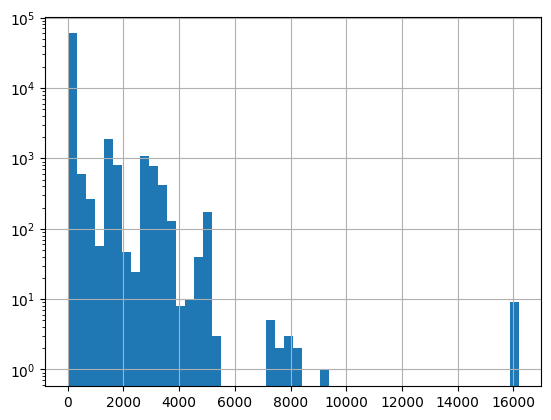

In [39]:
# sequence lengths
# logarithmic histogram
# ~ few hundred sequences longer than 4000
# large spikes at ribosomal RNA lengths
# 9 16000 length chains, which are mitochondrial genomes
# instead of filtering by length I will filter by familial coverage after joining
seqs["sequence"].str.len().hist(bins=50,log=True)

In [40]:
# very short (<15) sequences
# 23036 of the sequences are shorter than 15 letters
# these pieces are usually too short to match a family
seqs[seqs["sequence"].str.len() < 15].shape

(23036, 4)

In [41]:
# empty sequences
# there are no empty sequences
(seqs["sequence"].str.len() == 0).sum()

np.int64(0)

Other

In [42]:
# molecule names
# many names contain "DNA" or "RNA"
seqs["molecule_name"].value_counts()


,count
molecule_name,
STAPLE STRAND,1526
5S rRNA,941
mRNA,894
5S ribosomal RNA,892
16S rRNA,662
...,...
DNA (5'-D(*CP*CP*TP*GP*AP*CP*GP*TP*GP*GP*CP*TP*GP*G)-3'),1
DNA (5'-D(*TP*CP*AP*GP*TP*CP*GP*TP*GP*GP*TP*AP*TP*C)-3'),1
DNA (5'-D(*TP*GP*TP*GP*AP*TP*GP*TP*GP*GP*TP*AP*GP*G)-3'),1


In [43]:
# how pdb_id is written
# all letters in pdb_id are lowercase
# same as rfam
seqs["pdb_id"].str.islower().all()

np.True_

In [44]:
# how chain is written
# 5185 chain IDs have lowercase letters (not just upper)
# chain ids are case sensitive, so this is expected
# same as rfam
seqs["chain"].str.contains("[a-z]").sum()

np.int64(5185)

Columns to keep

In [45]:
# columns
seqs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65753 entries, 0 to 1169090
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   sequence       65753 non-null  object
 1   pdb_id         65753 non-null  object
 2   chain          65753 non-null  object
 3   molecule_name  65753 non-null  object
dtypes: object(4)
memory usage: 2.5+ MB


In [46]:
# keep sequence since thats the main data the model will train on
# keep pdb_id and chain since that's how the corresponding family in rfam is identified
# keep molecule_name for checking (not model input)

# Joining and exploring join

Merge

In [47]:
# merge based on pdb_id and chain
# some rows have the exact same pdb_id and chain
# because inner makes a row for each row in rfam
# that has a matching chain in seqs
join = pd.merge(seqs, rfam, on=["pdb_id", "chain"], how="inner")
join

,sequence,pdb_id,chain,molecule_name,rfam_acc,pdb_start,pdb_end,bit_score,evalue,cm_start,cm_end,hex_colour
0,UCCGUGAUAGUUUAAUGGUCAGAAUGGGCGCUUGUCGCGUGCCAGA...,1asy,R,T-RNA (75-MER),RF00005,1,72,56.3,1.100000e-12,1,71,00bac0
1,UCCGUGAUAGUUUAAUGGUCAGAAUGGGCGCUUGUCGCGUGCCAGA...,1asy,S,T-RNA (75-MER),RF00005,1,72,56.3,1.100000e-12,1,71,00bac0
2,UCCGUGAUAGUUUAAUGGUCAGAAUGGGCGCUUGUCGCGUGCCAGA...,1asz,R,T-RNA (75-MER),RF00005,1,72,56.3,1.100000e-12,1,71,00bac0
3,UCCGUGAUAGUUUAAUGGUCAGAAUGGGCGCUUGUCGCGUGCCAGA...,1asz,S,T-RNA (75-MER),RF00005,1,72,56.3,1.100000e-12,1,71,00bac0
4,GGCGCGUUAACAAAGCGGUUAUGUAGCGGAUUGCAAAUCCGUCUAG...,1b23,R,CYSTEINYL TRNA,RF00005,1,71,54.0,4.600000e-12,1,71,00bac0
...,...,...,...,...,...,...,...,...,...,...,...,...
12679,CGGUGAUUGGCGCAGCCUGGUAGCGCACUUCGUUCGGGACGAAGGG...,9wnr,Y,"P-tRNA(PRO), A-tRNA(PRO)",RF00005,1,74,60.7,6.600000e-14,1,71,00bac0
12680,CGGUGAUUGGCGCAGCCUGGUAGCGCACUUCGUUCGGGACGAAGGG...,9wnr,Z,"P-tRNA(PRO), A-tRNA(PRO)",RF00005,1,74,60.7,6.600000e-14,1,71,00bac0
12681,UGCCUGGCGGCCGUAGCGCGGUGGUCCCACCUGACCCCAUGCCGAA...,9wnr,a,5S rRNA,RF00001,3,118,92.8,8.900000e-22,1,120,00bac0
12682,GGUUAAGCGACUAAGCGUACACGGUGGAUGCCCUGGCAGUCAGAGG...,9wnr,b,23S rRNA,RF02541,1,2904,2878.6,0.000000e+00,1,2925,00bac0


In [48]:
# row counts
# 12806 rows in rfam vs 12684 rows in join
# 122 rows in rfam didn't find a match in seqs
join.shape

(12684, 12)

In [49]:
# rfam rows that didn't find a match
check = pd.merge(rfam, seqs, on=["pdb_id", "chain"], how="left", indicator=True)
check[check["_merge"] == "left_only"]["rfam_acc"].value_counts()

,count
rfam_acc,
RF00005,31
RF00001,23
RF00002,22
RF01960,22
RF02543,22
RF00177,1
RF02541,1


In [50]:
# total examples per family for each family with unmatched sequences
# since all unmatched sequences are in the 7 largest families
# the rows that didn't match are inconsequential
rfam["rfam_acc"].value_counts().head(7)


,count
rfam_acc,
RF00005,3222
RF00001,2175
RF02541,1714
RF00177,1650
RF02543,745
RF01960,700
RF00002,661


Chain coverage

count    12684.000000
mean         0.954583
std          0.134874
min          0.004202
25%          0.961039
50%          0.990576
75%          1.000000
max          1.000000
Name: coverage, dtype: float64


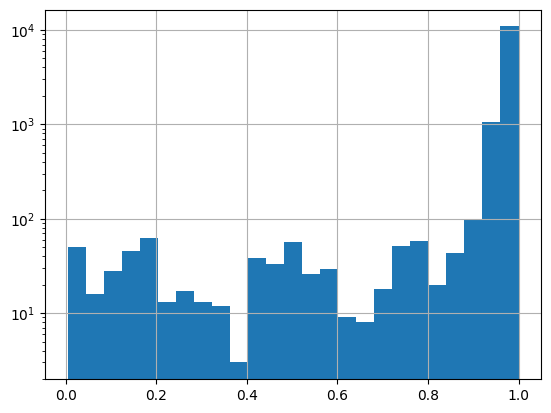

In [51]:
# chain coverage (proportion of chain that is part of a specific family)
# log scale
# more than half of chains are 99% familial matches,
# but there are still hundreds that are less than 0.8
join["coverage"] = (join["pdb_end"]-join["pdb_start"]+1)/join["sequence"].str.len()
join["coverage"].hist(bins=25, log=True)
print(join["coverage"].describe())

In [52]:
# only 586 rows are below 0.8,
# so I will only train on coverage above 0.8
(join["coverage"] < 0.8).sum()

np.int64(586)

Molecule type

In [53]:
# sequences with characters other than A, U, C, and G
# 905 sequences have non RNA characters
len(join[join["sequence"].str.replace("[AUCG]", "", regex=True).str.len()>0])

905

In [54]:
# family of sequences that contain characters other than AUCGTIXN
# every single one is tRNA
# tRNA holds amino acids so this is expected
join[join["sequence"].str.replace("[AUCGTIXN]", "", regex=True).str.len()>0]["rfam_acc"].value_counts()

,count
rfam_acc,
RF00005,34


In [55]:
# is there DNA?
# some of these 25 are actual DNA that will need removal based on name
# the non DNA rows are tRNA with ribothymidine
print(len(join[join["sequence"].str.contains("T")]))
join[join["sequence"].str.contains("T")][["sequence","pdb_id", "chain", "rfam_acc", "molecule_name"]]

25


,sequence,pdb_id,chain,rfam_acc,molecule_name
1890,GCUGAUAUAGCUCAGUUGGUAGAGCGCACCCUUGGUGAGGGUGAGG...,4v5g,AY,RF00005,A-SITE TRNA THR
1891,GCUGAUAUAGCUCAGUUGGUAGAGCGCACCCUUGGUGAGGGUGAGG...,4v5g,CY,RF00005,A-SITE TRNA THR
6076,GCCCGGAUAGCUCAGUCGGUAGAGCAUCAGACUUUUAAUCUGAGGG...,6wb0,D,RF00005,tRNA lysine 3
6078,GCCCGGAUAGCUCAGUCGGUAGAGCAUCAGACUUUUAAUCUGAGGG...,6wb1,D,RF00005,tRNA lysine 3
6080,GCCCGGAUAGCUCAGUCGGUAGAGCAUCAGACUUUUAAUCUGAGGG...,6wb2,D,RF00005,tRNA lysine 3
6847,TGTCTAATGTATGGACAGTGGATAAACACGCGCCCTGTAGCGGCGC...,7as5,AA,RF00240,SCAFFOLD STRAND
7214,CTGTGCCGTCCGTAACGTTGTCGATTTTTGTATTCCGGGGCCATGA...,7mi9,H,RF01330,DNA (72-MER)
7215,CTGTGCCGTCCGTAACGTTGTCGATTTTTGTATTCCGGGGCCATGA...,7mib,H,RF01330,DNA (64-MER)
9234,AACATGTCTGGACCCTGCCCTCATATCACCTGCGTTTCCGTTAAAC...,8ffz,I,RF00001,DNA (151-MER)
9301,GTGCAAGTCGTTTTGCTAGAGCTACATGTTCACTGCCGTGTAGGCA...,8flj,K,RF01317,"CRISPR repeat and prespacer, sense strand of DNA"


Duplicate sequences

In [56]:
# duplicate sequences
# 12684 - 10665 = 2019 distinct sequences
join.duplicated(subset=["sequence"]).sum()

np.int64(10665)

In [57]:
# duplicates within the same family
# 10665 - 10596 = 69 rows repeat a sequence seen in another family
join.duplicated(subset=["sequence", "rfam_acc"]).sum()

np.int64(10596)

# Cleaning

Drop unnecessary columns

In [58]:
# drop pdb_start and pdb_end since their info is already encoded in coverage
# drop bit_score and evalue since match quality is good for all
# drop cm_start and cm_end since partial matches are still useful examples
# drop hex_colour since it has no real meaning and is just an rfam convention
clean = join.drop(columns=["pdb_start", "pdb_end", "bit_score", "evalue", "cm_start", "cm_end", "hex_colour"])
clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sequence       12684 non-null  object 
 1   pdb_id         12684 non-null  object 
 2   chain          12684 non-null  object 
 3   molecule_name  12684 non-null  object 
 4   rfam_acc       12684 non-null  object 
 5   coverage       12684 non-null  float64
dtypes: float64(1), object(5)
memory usage: 594.7+ KB


Remove multi family chains

In [59]:
# collapse same family duplicates
clean = clean.drop_duplicates(subset=["pdb_id", "chain", "rfam_acc"])
clean.duplicated(subset=["pdb_id", "chain"]).sum()

np.int64(156)

In [60]:
# fully drop multi family chains
clean = clean[~clean.duplicated(subset=["pdb_id", "chain"], keep=False)]
clean.duplicated(subset=["pdb_id", "chain"]).sum()

np.int64(0)

In [61]:
# new shape
# 12684 - 12378 = 306 rows removed
clean.shape

(12378, 6)

Coverage cutoff

In [62]:
# drop rows with coverage below 0.8
# 12378 - 12057 = 321 rows dropped
clean = clean[clean["coverage"] >= 0.8]
clean.shape

(12057, 6)

DNA and nonstandard characters

In [63]:
# fraction of each sequence that isn't A, U, C, or G
clean["frac"] = clean["sequence"].str.replace("[AUCG]", "", regex=True).str.len() / clean["sequence"].str.len()
clean["frac"].describe()

,frac
count,12057.000000
mean,0.000759
std,0.007723
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.312500


,rfam_acc,molecule_name,frac
5800,RF01959,16S ribosomal rRNA,0.022044
5795,RF01959,16S ribosomal RNA,0.022044
9758,RF00005,tRNA Ser (88-MER),0.022727
5802,RF01959,16S ribosomal RNA,0.023946
12593,RF00001,5S rRNA,0.024000
...,...,...,...
12438,RF02543,Top strand for target rDNA,0.228571
9515,RF02543,28S DNA top strand,0.228571
12436,RF02543,Top strand for target rDNA,0.228571
11662,RF02543,28S DNA top strand,0.255924


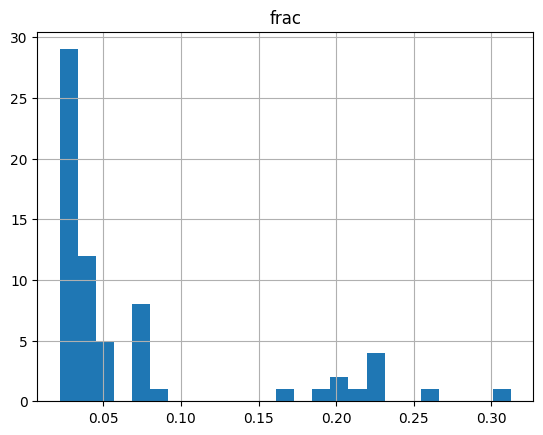

In [64]:
# rows above 2%
# fixable (non DNA) rows are less than 6%, and DNA rows are all 8%+
# visible gap in the chart
clean[clean["frac"] > 0.02][["rfam_acc", "molecule_name", "frac"]].sort_values("frac").hist(bins=25)
clean[clean["frac"] > 0.02][["rfam_acc", "molecule_name", "frac"]].sort_values("frac")

In [65]:
# drop sequences with frac > 0.06
# 12057 - 12037 = 20 sequences dropped
clean = clean[clean["frac"] <= 0.06]
clean.shape

(12037, 7)

In [66]:
# remaining sequences with characters other than A, U, C, G, N, and X
# 59 sequences have non RNA characters
len(clean[clean["sequence"].str.replace("[AUCGNX]", "", regex=True).str.len()>0])

59

In [67]:
# any remaining T is ribothymidine, a modified U
# I is inosine, a modified A
clean["sequence"] = clean["sequence"].str.replace("T", "U")
clean["sequence"] = clean["sequence"].str.replace("I", "A")

In [68]:
# remove amino acids and unknown positions
clean["sequence"] = clean["sequence"].str.replace("[^AUCG]", "", regex=True)

In [69]:
# check to make sure only A, U, C and G remain
clean["sequence"].str.replace("[AUCG]", "", regex=True).str.len().sum()

np.int64(0)

In [70]:
# remove frac
clean = clean.drop(columns=["frac"])

Deduplicate

In [71]:
# collapse duplicated sequences
# 12037 - 1806 = 10231 duplicates dropped
# this is expected, as much of the pdb is repeated tRNA and rRNA structures
clean = clean.drop_duplicates(subset=["sequence"])
print(clean.duplicated(subset=["sequence"]).sum())
print(clean.shape)

0
(1806, 6)


20 example minimum

In [72]:
# families with 20 or more examples
# 11 remaining families
(clean["rfam_acc"].value_counts() >= 20).sum()

np.int64(11)

In [73]:
# drop families with less than 20 examples
# 11 families remain
# 1806 - 1456 = 350 sequences dropped
keep = clean["rfam_acc"].value_counts()[clean["rfam_acc"].value_counts() >= 20].index
clean = clean[clean["rfam_acc"].isin(keep)]
print(clean["rfam_acc"].value_counts())
print(clean.shape)

rfam_acc
RF00005    393
RF02541    238
RF00177    202
RF02543    195
RF01960    159
RF00001    117
RF00002     43
RF02540     34
RF00167     30
RF00162     24
RF01959     21
Name: count, dtype: int64
(1456, 6)


Fix index

In [74]:
# reset index
clean = clean.reset_index(drop=True)
clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1456 entries, 0 to 1455
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sequence       1456 non-null   object 
 1   pdb_id         1456 non-null   object 
 2   chain          1456 non-null   object 
 3   molecule_name  1456 non-null   object 
 4   rfam_acc       1456 non-null   object 
 5   coverage       1456 non-null   float64
dtypes: float64(1), object(5)
memory usage: 68.4+ KB


In [75]:
# final shape
clean.shape

(1456, 6)

# Final Check

In [76]:
#shape
# 1456 rows and 6 columns
clean.shape

(1456, 6)

In [77]:
# missing values
# no missing values
clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1456 entries, 0 to 1455
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sequence       1456 non-null   object 
 1   pdb_id         1456 non-null   object 
 2   chain          1456 non-null   object 
 3   molecule_name  1456 non-null   object 
 4   rfam_acc       1456 non-null   object 
 5   coverage       1456 non-null   float64
dtypes: float64(1), object(5)
memory usage: 68.4+ KB


In [78]:
# full row duplicates
# none
clean.duplicated().sum()

np.int64(0)

In [79]:
# sequence duplicates
# none
clean.duplicated(subset=["sequence"]).sum()

np.int64(0)

In [80]:
# pdb_id and chain duplicates
# none
clean.duplicated(subset=["pdb_id", "chain"]).sum()

np.int64(0)

In [81]:
# family value counts
# all >= 20
clean["rfam_acc"].value_counts()

,count
rfam_acc,
RF00005,393
RF02541,238
RF00177,202
RF02543,195
RF01960,159
RF00001,117
RF00002,43
RF02540,34
RF00167,30


The model will use sequence as input and rfam_acc as label

# Is the data enough?

Choosing to start with PDB data limits me to RNAs with solved structures, so only 1,456 distinct sequences in 11 families survive, heavily weighted towards ribosomal and transfer RNA. Rfam's per family sequence files could give more varied examples of the same families, but those labels come from Rfam's own models, so it would kind of be circular. If I did want to add that data, I'd do it by family ID, since it would add new rows not columns.

# Preparing features (extra)

In [82]:
# imports
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [83]:
# input is sequences, label is family
X_text = clean["sequence"]
y = clean["rfam_acc"]

In [84]:
# count every 4-mer and convert each row to proportions
# 4 letters gives 4^4 = 256 possible 4-mers
# plain counts with no extra weighting
# norm="l1" so a 5000 letter rRNA is comparable to a 76 letter tRNA
vec = TfidfVectorizer(analyzer = "char", ngram_range = (4,4), lowercase = False,
                      use_idf = False, norm = "l1")
X = vec.fit_transform(X_text)
X.shape

(1456, 256)

In [85]:
# 80/20 train test split
# stratify by family since some families are tiny
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, stratify = y, random_state = 42)
print(X_train.shape)
print(X_test.shape)

(1164, 256)
(292, 256)


In [86]:
# make sure stratification worked
y_test.value_counts()

,count
rfam_acc,
RF00005,79
RF02541,48
RF00177,40
RF02543,39
RF01960,32
RF00001,23
RF00002,9
RF02540,7
RF00167,6


# Training and testing

In [87]:
# train a random forest on the k-mer proportions
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [88]:
# predict on test set and check accuracy
pred = model.predict(X_test)
model.score(X_test, y_test)

0.976027397260274

In [89]:
# per family results
# overall accuracy is mostly accuracy on large families
# this shows how it does on small families also
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

     RF00001       0.92      1.00      0.96        23
     RF00002       1.00      1.00      1.00         9
     RF00005       0.95      1.00      0.98        79
     RF00162       1.00      1.00      1.00         5
     RF00167       1.00      0.83      0.91         6
     RF00177       1.00      0.97      0.99        40
     RF01959       1.00      1.00      1.00         4
     RF01960       1.00      0.97      0.98        32
     RF02540       1.00      0.71      0.83         7
     RF02541       0.98      0.98      0.98        48
     RF02543       1.00      0.97      0.99        39

    accuracy                           0.98       292
   macro avg       0.99      0.95      0.96       292
weighted avg       0.98      0.98      0.98       292



In [90]:
# comparison to the same model only using sequence length
# shows how much the k-mers actually add
L = clean[["sequence"]].apply(lambda col: col.str.len())
L_train, L_test, _, _ = train_test_split(
    L, y, test_size = 0.2, stratify = y, random_state = 42)

length_model = RandomForestClassifier(random_state=42)
length_model.fit(L_train, y_train)
length_pred = length_model.predict(L_test)
length_model.score(L_test, y_test)

0.863013698630137

In [91]:
print(classification_report(y_test, length_pred))

              precision    recall  f1-score   support

     RF00001       0.92      1.00      0.96        23
     RF00002       1.00      0.78      0.88         9
     RF00005       0.95      0.95      0.95        79
     RF00162       1.00      1.00      1.00         5
     RF00167       0.57      0.67      0.62         6
     RF00177       0.88      0.75      0.81        40
     RF01959       0.33      0.50      0.40         4
     RF01960       0.76      0.88      0.81        32
     RF02540       0.62      0.71      0.67         7
     RF02541       0.90      0.77      0.83        48
     RF02543       0.84      0.92      0.88        39

    accuracy                           0.86       292
   macro avg       0.80      0.81      0.80       292
weighted avg       0.87      0.86      0.86       292



The k-mer model reached 0.98 accuracy compared to 0.86 for the same model using only sequence length. Length alone does decently because many families have very different typical lengths, but k-mers cut the error rate from 14% to 2%.

There are two main limitations to the 0.98 value. First, six of the 11 families are the same molecule, SSU or LSU rRNA, split by domain of life, so some of what the k-mers pick up could be organism-level composition like GC content rather than anything about the families specifically. Second, I removed exact duplicate sequences, but near-identical sequences from related organisms can still be on both sides of the train/test split, which probably inflates the score. Splitting by sequence-identity clusters instead of randomly would likely be a fairer test.

So short local patterns are enough to separate these 11 families on this split, but this may not hold up for test sequences that have no close homologs in the training set, rather than just no exact matches.